<a href="https://colab.research.google.com/github/preranna-1/Machine-learning-project/blob/main/Loan_Default_Prediction_ML_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


print("SECTION 1: DATA LOADING AND EXPLORATION\n")


file_path = '/content/drive/MyDrive/ML_Project/Classification_Project/credit_risk_dataset.csv'
df = pd.read_csv(file_path)
print(f"✓ Dataset loaded successfully from my drive")


SECTION 1: DATA LOADING AND EXPLORATION

✓ Dataset loaded successfully from my drive


In [ ]:
# ============================================
# SECTION 2.1: HANDLING MISSING VALUES
# ============================================

from sklearn.impute import SimpleImputer


print("STEP 2.1: HANDLING MISSING VALUES\n")


# Create copy for processing
df_processed = df.copy()

# Identify columns
numerical_cols = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()

# Remove target from numerical
if 'loan_status' in numerical_cols:
    numerical_cols.remove('loan_status')

print(f"Missing before: {df_processed.isnull().sum().sum()}")

# Impute numerical with median
if numerical_cols:
    num_imputer = SimpleImputer(strategy='median')
    df_processed[numerical_cols] = num_imputer.fit_transform(df_processed[numerical_cols])

# Impute categorical with most frequent
if categorical_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df_processed[categorical_cols] = cat_imputer.fit_transform(df_processed[categorical_cols])

print(f"Missing after: {df_processed.isnull().sum().sum()}")
print("✓ Missing values handled")

STEP 2.1: HANDLING MISSING VALUES

Missing before: 4011
Missing after: 0
✓ Missing values handled


In [ ]:
# ============================================================================
# Section 2.2: Encoding Categorical Variables
# ============================================================================

from sklearn.preprocessing import LabelEncoder

print("SECTION 2.2: ENCODING CATEGORICAL VARIABLES\n")

# Label Encoding for binary categorical variables
label_encoder = LabelEncoder()
df_processed['person_home_ownership'] = label_encoder.fit_transform(df_processed['person_home_ownership'])
df_processed['loan_intent'] = label_encoder.fit_transform(df_processed['loan_intent'])
df_processed['loan_grade'] = label_encoder.fit_transform(df_processed['loan_grade'])
df_processed['cb_person_default_on_file'] = label_encoder.fit_transform(df_processed['cb_person_default_on_file'])

# One-Hot Encoding for nominal categorical variables
# (If there are any remaining categorical columns, use get_dummies)
# df_processed = pd.get_dummies(df_processed, columns=['categorical_column1', 'categorical_column2'], drop_first=True)

print("✓ Categorical variables encoded successfully")
print("\nDataset shape after encoding:", df_processed.shape)
print("\nFirst few rows after encoding:")
print(df_processed.head())

SECTION 2.2: ENCODING CATEGORICAL VARIABLES

✓ Categorical variables encoded successfully

Dataset shape after encoding: (32581, 12)

First few rows after encoding:
   person_age  person_income  person_home_ownership  person_emp_length  \
0        22.0        59000.0                      3              123.0   
1        21.0         9600.0                      2                5.0   
2        25.0         9600.0                      0                1.0   
3        23.0        65500.0                      3                4.0   
4        24.0        54400.0                      3                8.0   

   loan_intent  loan_grade  loan_amnt  loan_int_rate  loan_status  \
0            4           3    35000.0          16.02            1   
1            1           1     1000.0          11.14            0   
2            3           2     5500.0          12.87            1   
3            3           2    35000.0          15.23            1   
4            3           2    35000.0        

In [ ]:
# ============================================================================
# Section 2.3: Feature Scaling
# ============================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


print("SECTION 2.3: FEATURE SCALING\n")


# Separate features and target
X = df_processed.drop('loan_status', axis=1)
y = df_processed['loan_status']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split data first (before scaling)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Apply standardization (fit on training data only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Feature scaling completed successfully")
print(f"Scaled training set shape: {X_train_scaled.shape}")
print(f"Scaled test set shape: {X_test_scaled.shape}")

SECTION 2.3: FEATURE SCALING


Features shape: (32581, 11)
Target shape: (32581,)

Training set size: 22806
Test set size: 9775

✓ Feature scaling completed successfully
Scaled training set shape: (22806, 11)
Scaled test set shape: (9775, 11)


In [ ]:
# ============================================================================
# Section 2.4: Handling Class Imbalance (if applicable)
# ============================================================================

from imblearn.over_sampling import SMOTE


print("SECTION 2.4: HANDLING CLASS IMBALANCE\n")


# Check class distribution
print("\nBefore SMOTE:", y_train.value_counts())
print("\n")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", pd.Series(y_train_balanced).value_counts())

print("\n✓ Class balancing completed successfully")

SECTION 2.4: HANDLING CLASS IMBALANCE


Before SMOTE: loan_status
0    17831
1     4975
Name: count, dtype: int64


After SMOTE: loan_status
0    17831
1    17831
Name: count, dtype: int64

✓ Class balancing completed successfully


In [ ]:
# ============================================================================
# Section 3.1: Decision Tree Classifier
# ============================================================================

from sklearn.tree import DecisionTreeClassifier


print("SECTION 3.1: DECISION TREE CLASSIFIER\n")


# Create and train the model
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_balanced, y_train_balanced)

# Make predictions
dt_predictions = dt_model.predict(X_test_scaled)
dt_pred_proba = dt_model.predict_proba(X_test_scaled)[:, 1]

print("✓ Decision Tree trained successfully")

SECTION 3.1: DECISION TREE CLASSIFIER

✓ Decision Tree trained successfully


In [ ]:
# ============================================================================
# Section 3.2: Random Forest Classifier
# ============================================================================

from sklearn.ensemble import RandomForestClassifier


print("SECTION 3.2: RANDOM FOREST CLASSIFIER\n")


# Create and train the model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)

# Make predictions
rf_predictions = rf_model.predict(X_test_scaled)
rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print("✓ Random Forest trained successfully")

SECTION 3.2: RANDOM FOREST CLASSIFIER

✓ Random Forest trained successfully


In [ ]:
# ============================================================================
# Section 3.3: K-Nearest Neighbors (KNN)
# ============================================================================

from sklearn.neighbors import KNeighborsClassifier


print("SECTION 3.3: K-NEAREST NEIGHBORS (KNN)\n")

# Create and train the model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_balanced, y_train_balanced)

# Make predictions
knn_predictions = knn_model.predict(X_test_scaled)
knn_pred_proba = knn_model.predict_proba(X_test_scaled)[:, 1]

print("✓ KNN trained successfully")

SECTION 3.3: K-NEAREST NEIGHBORS (KNN)

✓ KNN trained successfully


In [ ]:
# ============================================================================
# Section 3.4: Naive Bayes Classifier
# ============================================================================

from sklearn.naive_bayes import GaussianNB

print("SECTION 3.4: NAIVE BAYES CLASSIFIER\n")


# Create and train the model
nb_model = GaussianNB()
nb_model.fit(X_train_balanced, y_train_balanced)

# Make predictions
nb_predictions = nb_model.predict(X_test_scaled)
nb_pred_proba = nb_model.predict_proba(X_test_scaled)[:, 1]

print("✓ Naive Bayes trained successfully")

SECTION 3.4: NAIVE BAYES CLASSIFIER

✓ Naive Bayes trained successfully


SECTION 3.5: QUICK MODEL COMPARISON


Model Accuracies:
Decision Tree:    0.9099
Random Forest:    0.9141
KNN:              0.7884
Naive Bayes:      0.7493


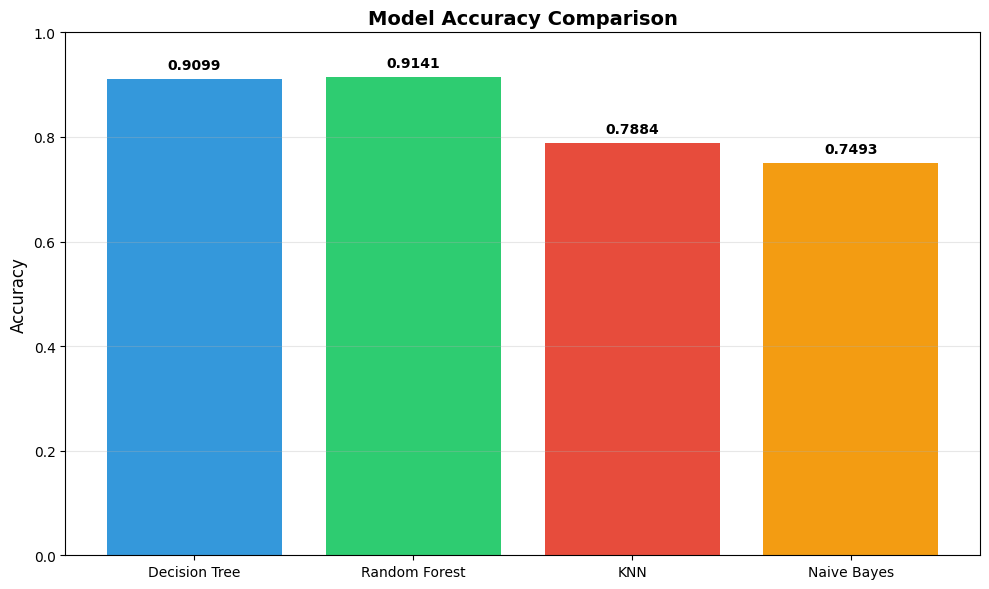


✓ Quick comparison completed


In [ ]:
# ============================================================================
# Section 3.5: Quick Model Comparison
# ============================================================================

from sklearn.metrics import accuracy_score


print("SECTION 3.5: QUICK MODEL COMPARISON\n")


# Calculate accuracy for all models
dt_accuracy = accuracy_score(y_test, dt_predictions)
rf_accuracy = accuracy_score(y_test, rf_predictions)
knn_accuracy = accuracy_score(y_test, knn_predictions)
nb_accuracy = accuracy_score(y_test, nb_predictions)

# Display results
print("\nModel Accuracies:")
print(f"Decision Tree:    {dt_accuracy:.4f}")
print(f"Random Forest:    {rf_accuracy:.4f}")
print(f"KNN:              {knn_accuracy:.4f}")
print(f"Naive Bayes:      {nb_accuracy:.4f}")

# Visualize comparison
models = ['Decision Tree', 'Random Forest', 'KNN', 'Naive Bayes']
accuracies = [dt_accuracy, rf_accuracy, knn_accuracy, nb_accuracy]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylim(0, 1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Quick comparison completed")

In [ ]:

# ============================================================================
# Section 4: Model Evaluation
# ============================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


print("SECTION 4: MODEL EVALUATION\n")

# ============================================================================
# 4.1 Basic Performance Metrics
# ============================================================================


print("4.1 BASIC PERFORMANCE METRICS\n")

# Function to calculate all metrics
def calculate_metrics(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n{model_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    return accuracy, precision, recall, f1

# Calculate metrics for all models
dt_metrics = calculate_metrics("Decision Tree", y_test, dt_predictions)
rf_metrics = calculate_metrics("Random Forest", y_test, rf_predictions)
knn_metrics = calculate_metrics("KNN", y_test, knn_predictions)
nb_metrics = calculate_metrics("Naive Bayes", y_test, nb_predictions)

SECTION 4: MODEL EVALUATION

4.1 BASIC PERFORMANCE METRICS


Decision Tree:
  Accuracy:  0.9099
  Precision: 0.9073
  Recall:    0.9099
  F1-Score:  0.9069

Random Forest:
  Accuracy:  0.9141
  Precision: 0.9118
  Recall:    0.9141
  F1-Score:  0.9113

KNN:
  Accuracy:  0.7884
  Precision: 0.8301
  Recall:    0.7884
  F1-Score:  0.8011

Naive Bayes:
  Accuracy:  0.7493
  Precision: 0.8235
  Recall:    0.7493
  F1-Score:  0.7685


4.2 CONFUSION MATRICES



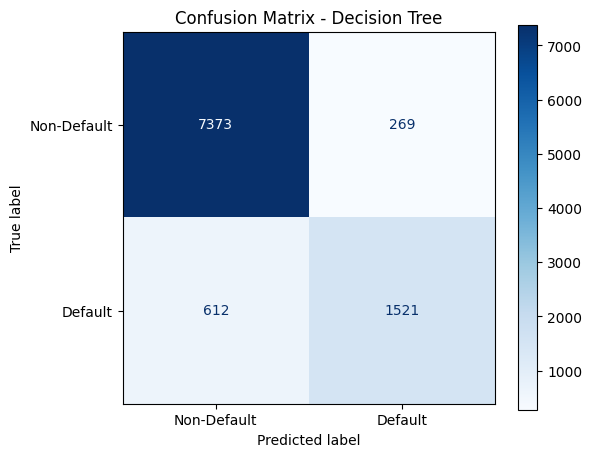

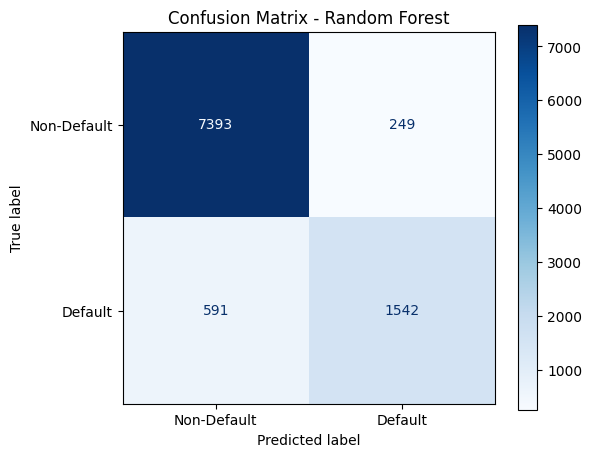

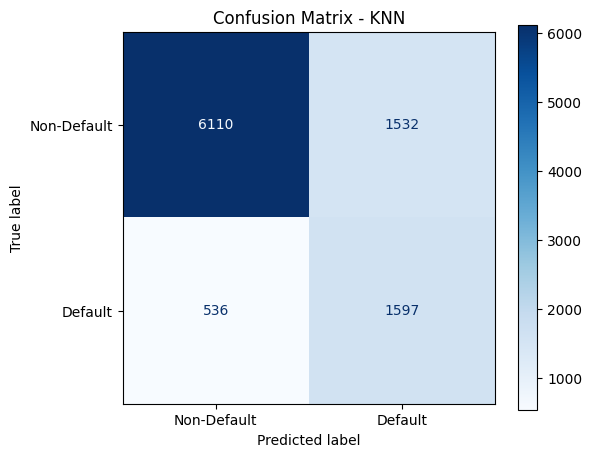

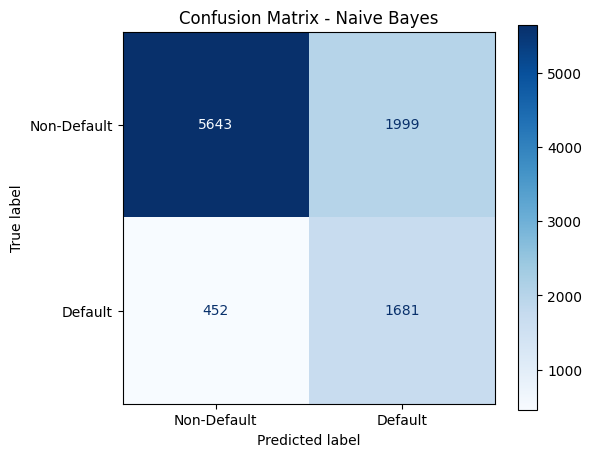

In [ ]:
# ============================================================================
# 4.2 Confusion Matrix
# ============================================================================


print("4.2 CONFUSION MATRICES\n")


# Function to plot confusion matrix
def plot_confusion_matrix(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm, display_labels=['Non-Default', 'Default']).plot(ax=ax, cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

# Plot confusion matrices for all models
plot_confusion_matrix("Decision Tree", y_test, dt_predictions)
plot_confusion_matrix("Random Forest", y_test, rf_predictions)
plot_confusion_matrix("KNN", y_test, knn_predictions)
plot_confusion_matrix("Naive Bayes", y_test, nb_predictions)


In [ ]:
# ============================================================================
# OVERFITTING CHECK: Training vs Test Accuracy Comparison
# ============================================================================

from sklearn.metrics import accuracy_score

print("\n" + "="*80)
print("OVERFITTING CHECK: TRAINING VS TEST ACCURACY")
print("="*80)

# Calculate training accuracies
dt_train_acc = accuracy_score(y_train_balanced, dt_model.predict(X_train_balanced))
rf_train_acc = accuracy_score(y_train_balanced, rf_model.predict(X_train_balanced))
knn_train_acc = accuracy_score(y_train_balanced, knn_model.predict(X_train_balanced))
nb_train_acc = accuracy_score(y_train_balanced, nb_model.predict(X_train_balanced))

# Get test accuracies
dt_test_acc = accuracy_score(y_test, dt_predictions)
rf_test_acc = accuracy_score(y_test, rf_predictions)
knn_test_acc = accuracy_score(y_test, knn_predictions)
nb_test_acc = accuracy_score(y_test, nb_predictions)

# Calculate differences
dt_diff = dt_train_acc - dt_test_acc
rf_diff = rf_train_acc - rf_test_acc
knn_diff = knn_train_acc - knn_test_acc
nb_diff = nb_train_acc - nb_test_acc

# Print comparison
print("\nTraining vs Test Accuracy:")
print(f"Decision Tree: Train={dt_train_acc:.4f}, Test={dt_test_acc:.4f}, Diff={dt_diff:.4f}")
print(f"Random Forest: Train={rf_train_acc:.4f}, Test={rf_test_acc:.4f}, Diff={rf_diff:.4f}")
print(f"KNN:           Train={knn_train_acc:.4f}, Test={knn_test_acc:.4f}, Diff={knn_diff:.4f}")
print(f"Naive Bayes:   Train={nb_train_acc:.4f}, Test={nb_test_acc:.4f}, Diff={nb_diff:.4f}")


OVERFITTING CHECK: TRAINING VS TEST ACCURACY

Training vs Test Accuracy:
Decision Tree: Train=0.8492, Test=0.9099, Diff=-0.0607
Random Forest: Train=0.8948, Test=0.9141, Diff=-0.0193
KNN:           Train=0.9251, Test=0.7884, Diff=0.1366
Naive Bayes:   Train=0.7603, Test=0.7493, Diff=0.0110


In [ ]:
# ============================================================================
# 4.3 Classification Report
# ============================================================================

print("Decision Tree Classification Report: \n")

print(classification_report(y_test, dt_predictions, target_names=['Non-Default', 'Default']))


print("Random Forest Classification Report:\n")

print(classification_report(y_test, rf_predictions, target_names=['Non-Default', 'Default']))


print("KNN Classification Report:\n")
print(classification_report(y_test, knn_predictions, target_names=['Non-Default', 'Default']))


print("Naive Bayes Classification Report:\n")
print(classification_report(y_test, nb_predictions, target_names=['Non-Default', 'Default']))


print("✓ Model evaluation completed")


Decision Tree Classification Report: 

              precision    recall  f1-score   support

 Non-Default       0.92      0.96      0.94      7642
     Default       0.85      0.71      0.78      2133

    accuracy                           0.91      9775
   macro avg       0.89      0.84      0.86      9775
weighted avg       0.91      0.91      0.91      9775

Random Forest Classification Report:

              precision    recall  f1-score   support

 Non-Default       0.93      0.97      0.95      7642
     Default       0.86      0.72      0.79      2133

    accuracy                           0.91      9775
   macro avg       0.89      0.85      0.87      9775
weighted avg       0.91      0.91      0.91      9775

KNN Classification Report:

              precision    recall  f1-score   support

 Non-Default       0.92      0.80      0.86      7642
     Default       0.51      0.75      0.61      2133

    accuracy                           0.79      9775
   macro avg       0.71

In [ ]:
# ============================================================================
# Section 4.4: K-Fold Cross-Validation
# ============================================================================

from sklearn.model_selection import cross_val_score


print("SECTION 4.4: K-FOLD CROSS-VALIDATION\n")


# Function to perform cross-validation
def perform_cross_validation(model, model_name, X, y, cv=5):
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    print(f"\n{model_name} Cross-Validation Results:")
    print(f"CV Scores: {cv_scores}")
    print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
    print(f"Standard Deviation: {cv_scores.std():.4f}")
    return cv_scores.mean(), cv_scores.std()

# Perform cross-validation for all models
print("\nPerforming 5-Fold Cross-Validation on all models...")
print("-" * 80)

dt_cv_mean, dt_cv_std = perform_cross_validation(dt_model, "Decision Tree", X_train_balanced, y_train_balanced)
rf_cv_mean, rf_cv_std = perform_cross_validation(rf_model, "Random Forest", X_train_balanced, y_train_balanced)
knn_cv_mean, knn_cv_std = perform_cross_validation(knn_model, "KNN", X_train_balanced, y_train_balanced)
nb_cv_mean, nb_cv_std = perform_cross_validation(nb_model, "Naive Bayes", X_train_balanced, y_train_balanced)

# Summary comparison

print("CROSS-VALIDATION SUMMARY\n")


cv_results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'KNN', 'Naive Bayes'],
    'Mean CV Accuracy': [dt_cv_mean, rf_cv_mean, knn_cv_mean, nb_cv_mean],
    'Std Deviation': [dt_cv_std, rf_cv_std, knn_cv_std, nb_cv_std]
})

print("\n", cv_results.to_string(index=False))

print("\n")
print("✓ Cross-validation completed")


SECTION 4.4: K-FOLD CROSS-VALIDATION


Performing 5-Fold Cross-Validation on all models...
--------------------------------------------------------------------------------

Decision Tree Cross-Validation Results:
CV Scores: [0.82770223 0.84732931 0.85011217 0.85712283 0.85221537]
Mean CV Accuracy: 0.8469
Standard Deviation: 0.0101

Random Forest Cross-Validation Results:
CV Scores: [0.85055376 0.8776111  0.88390353 0.88698822 0.88320247]
Mean CV Accuracy: 0.8765
Standard Deviation: 0.0133

KNN Cross-Validation Results:
CV Scores: [0.8626104  0.87032104 0.88067863 0.88867078 0.88222098]
Mean CV Accuracy: 0.8769
Standard Deviation: 0.0093

Naive Bayes Cross-Validation Results:
CV Scores: [0.75690453 0.76377401 0.76303982 0.75715087 0.75757151]
Mean CV Accuracy: 0.7597
Standard Deviation: 0.0031
CROSS-VALIDATION SUMMARY


         Model  Mean CV Accuracy  Std Deviation
Decision Tree          0.846896       0.010117
Random Forest          0.876452       0.013298
          KNN          0.87

SECTION 5: MODEL COMPARISON

        Model  Accuracy  Precision   Recall  F1-Score
Decision Tree  0.909872   0.907288 0.909872  0.906921
Random Forest  0.914066   0.911792 0.914066  0.911262
          KNN  0.788440   0.830110 0.788440  0.801088
  Naive Bayes  0.749258   0.823490 0.749258  0.768504

✓ Model comparison completed

ROC CURVE AND AUC



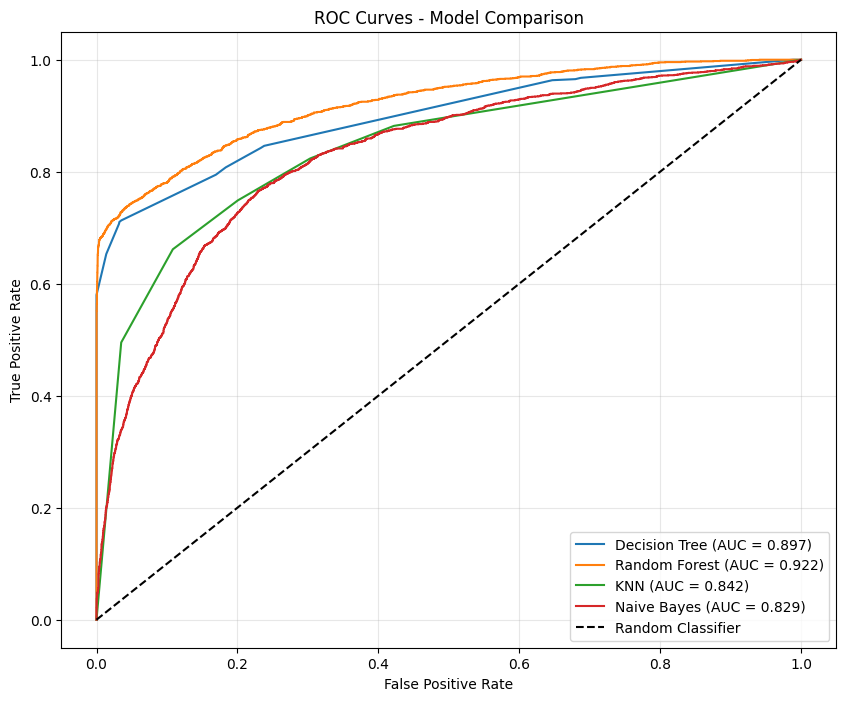


AUC Scores:
Decision Tree: 0.8975
Random Forest: 0.9218
KNN:           0.8419
Naive Bayes:   0.8295

✓ ROC Curve and AUC analysis completed


In [ ]:
# ============================================================================
# SECTION 5: MODEL COMPARISON
# ============================================================================


print("SECTION 5: MODEL COMPARISON\n")


# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'KNN', 'Naive Bayes'],
    'Accuracy': [dt_metrics[0], rf_metrics[0], knn_metrics[0], nb_metrics[0]],
    'Precision': [dt_metrics[1], rf_metrics[1], knn_metrics[1], nb_metrics[1]],
    'Recall': [dt_metrics[2], rf_metrics[2], knn_metrics[2], nb_metrics[2]],
    'F1-Score': [dt_metrics[3], rf_metrics[3], knn_metrics[3], nb_metrics[3]]
})


print(comparison_df.to_string(index=False))

print("\n✓ Model comparison completed\n")

# ============================================================================
# ROC CURVE AND AUC
# ============================================================================

from sklearn.metrics import roc_curve, auc


print("ROC CURVE AND AUC\n")


# Calculate and plot ROC curves
plt.figure(figsize=(10, 8))

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_pred_proba)
auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')

# KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_pred_proba)
auc_knn = auc(fpr_knn, tpr_knn)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.3f})')

# Naive Bayes
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_pred_proba)
auc_nb = auc(fpr_nb, tpr_nb)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.3f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Print AUC scores
print("\nAUC Scores:")
print(f"Decision Tree: {auc_dt:.4f}")
print(f"Random Forest: {auc_rf:.4f}")
print(f"KNN:           {auc_knn:.4f}")
print(f"Naive Bayes:   {auc_nb:.4f}")

print("\n✓ ROC Curve and AUC analysis completed")


SECTION 6: PERFORMANCE WITH VS WITHOUT PREPROCESSING


Training models WITHOUT preprocessing...

COMPARISON RESULTS
Model           Without Prep    With Prep       Improvement
--------------------------------------------------------------------------------
Decision Tree   0.9099          0.9099          +0.0000
Random Forest   0.9249          0.9141          -0.0108
KNN             0.8340          0.7884          -0.0455
Naive Bayes     0.8198          0.7493          -0.0706


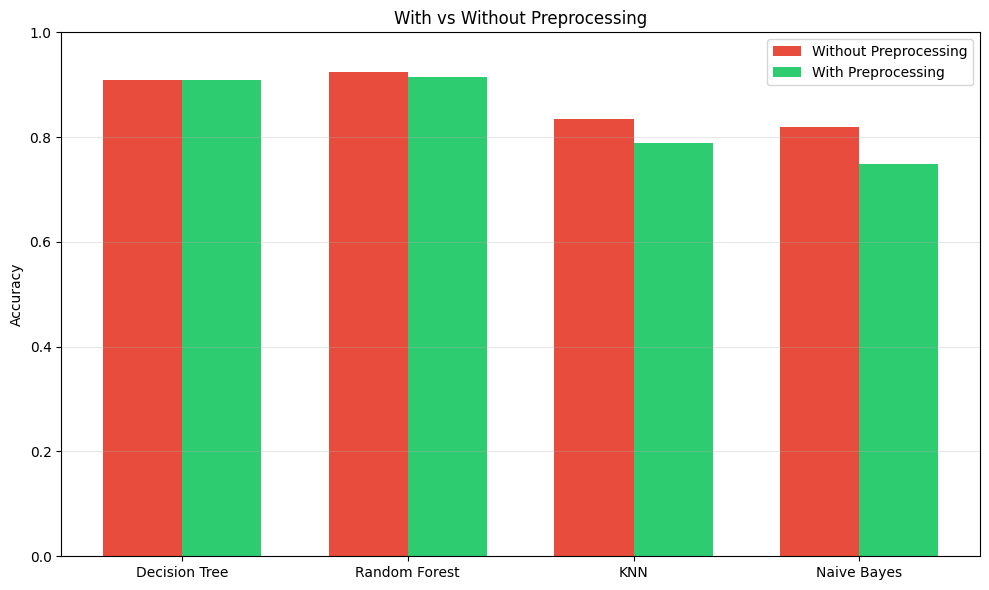


✓ Preprocessing comparison completed


In [ ]:
# ============================================================================
# SECTION 6: PERFORMANCE WITH VS WITHOUT PREPROCESSING
# ============================================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


print("SECTION 6: PERFORMANCE WITH VS WITHOUT PREPROCESSING\n")


# Prepare data without preprocessing (no scaling, no SMOTE)
X_raw = df_processed.drop('loan_status', axis=1)
y_raw = df_processed['loan_status']

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.3, random_state=42, stratify=y_raw
)

# Train models without preprocessing
print("\nTraining models WITHOUT preprocessing...")
dt_raw = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_raw.fit(X_train_raw, y_train_raw)

rf_raw = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_raw.fit(X_train_raw, y_train_raw)

knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train_raw, y_train_raw)

nb_raw = GaussianNB()
nb_raw.fit(X_train_raw, y_train_raw)

# Get accuracies without preprocessing
dt_acc_raw = accuracy_score(y_test_raw, dt_raw.predict(X_test_raw))
rf_acc_raw = accuracy_score(y_test_raw, rf_raw.predict(X_test_raw))
knn_acc_raw = accuracy_score(y_test_raw, knn_raw.predict(X_test_raw))
nb_acc_raw = accuracy_score(y_test_raw, nb_raw.predict(X_test_raw))

# Get accuracies with preprocessing (from Section 4)
dt_acc_prep = dt_metrics[0]
rf_acc_prep = rf_metrics[0]
knn_acc_prep = knn_metrics[0]
nb_acc_prep = nb_metrics[0]

# Comparison
print("\n" + "="*80)
print("COMPARISON RESULTS")
print("="*80)
print(f"{'Model':<15} {'Without Prep':<15} {'With Prep':<15} {'Improvement'}")
print("-" * 80)
print(f"{'Decision Tree':<15} {dt_acc_raw:<15.4f} {dt_acc_prep:<15.4f} {dt_acc_prep-dt_acc_raw:+.4f}")
print(f"{'Random Forest':<15} {rf_acc_raw:<15.4f} {rf_acc_prep:<15.4f} {rf_acc_prep-rf_acc_raw:+.4f}")
print(f"{'KNN':<15} {knn_acc_raw:<15.4f} {knn_acc_prep:<15.4f} {knn_acc_prep-knn_acc_raw:+.4f}")
print(f"{'Naive Bayes':<15} {nb_acc_raw:<15.4f} {nb_acc_prep:<15.4f} {nb_acc_prep-nb_acc_raw:+.4f}")

# Visualization
models = ['Decision Tree', 'Random Forest', 'KNN', 'Naive Bayes']
without_prep = [dt_acc_raw, rf_acc_raw, knn_acc_raw, nb_acc_raw]
with_prep = [dt_acc_prep, rf_acc_prep, knn_acc_prep, nb_acc_prep]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, without_prep, width, label='Without Preprocessing', color='#e74c3c')
ax.bar(x + width/2, with_prep, width, label='With Preprocessing', color='#2ecc71')

ax.set_ylabel('Accuracy')
ax.set_title('With vs Without Preprocessing')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Preprocessing comparison completed")
